In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset
df = pd.read_csv("hr_analytics_advanced.csv")


In [3]:
# Basic Info
print(df.head())        # First 5 rows
print(df.tail())        # Last 5 rows
print(df.shape)         # Rows & columns
print(df.columns)       # Column names
print(df.info())        # Data types
print(df.describe())    # Statistical summary


   EmpID  Age AgeGroup Attrition     BusinessTravel  DailyRate  \
0  RM297   18    18-25       Yes      Travel_Rarely        230   
1  RM302   18    18-25        No      Travel_Rarely        812   
2  RM458   18    18-25       Yes  Travel_Frequently       1306   
3  RM728   18    18-25        No         Non-Travel        287   
4  RM829   18    18-25       Yes         Non-Travel        247   

               Department  DistanceFromHome  Education EducationField  ...  \
0  Research & Development                 3          3  Life Sciences  ...   
1                   Sales                10          3        Medical  ...   
2                   Sales                 5          3      Marketing  ...   
3  Research & Development                 5          2  Life Sciences  ...   
4  Research & Development                 8          1        Medical  ...   

   RelationshipSatisfaction  StandardHours  StockOptionLevel  \
0                         3             80                 0   
1     

In [4]:
# Check Missing Values
print(df.isnull().sum())

EmpID                        0
Age                          0
AgeGroup                     0
Attrition                    0
BusinessTravel               0
DailyRate                    0
Department                   0
DistanceFromHome             0
Education                    0
EducationField               0
EmployeeCount                0
EmployeeNumber               0
EnvironmentSatisfaction      0
Gender                       0
HourlyRate                   0
JobInvolvement               0
JobLevel                     0
JobRole                      0
JobSatisfaction              0
MaritalStatus                0
MonthlyIncome                0
SalarySlab                   0
MonthlyRate                  0
NumCompaniesWorked           0
Over18                       0
OverTime                     0
PercentSalaryHike            0
PerformanceRating            0
RelationshipSatisfaction     0
StandardHours                0
StockOptionLevel             0
TotalWorkingYears            0
Training

In [5]:
#Duplicate Check
print(df.duplicated().sum())

7


In [6]:
#Unique Values
for col in df.columns:
    print(col, ":", df[col].nunique())

EmpID : 1470
Age : 43
AgeGroup : 5
Attrition : 2
BusinessTravel : 4
DailyRate : 886
Department : 3
DistanceFromHome : 29
Education : 5
EducationField : 6
EmployeeCount : 1
EmployeeNumber : 1470
EnvironmentSatisfaction : 4
Gender : 2
HourlyRate : 71
JobInvolvement : 4
JobLevel : 5
JobRole : 9
JobSatisfaction : 4
MaritalStatus : 3
MonthlyIncome : 1349
SalarySlab : 4
MonthlyRate : 1427
NumCompaniesWorked : 10
Over18 : 1
OverTime : 2
PercentSalaryHike : 15
PerformanceRating : 2
RelationshipSatisfaction : 4
StandardHours : 1
StockOptionLevel : 4
TotalWorkingYears : 40
TrainingTimesLastYear : 7
WorkLifeBalance : 4
YearsAtCompany : 37
YearsInCurrentRole : 19
YearsSinceLastPromotion : 16
YearsWithCurrManager : 18


In [7]:
#Correlation
correlation = df.corr(numeric_only=True)
print(correlation)

                               Age  DailyRate  DistanceFromHome  Education  \
Age                       1.000000   0.011584         -0.000329   0.205689   
DailyRate                 0.011584   1.000000         -0.007134  -0.016750   
DistanceFromHome         -0.000329  -0.007134          1.000000   0.019661   
Education                 0.205689  -0.016750          0.019661   1.000000   
EmployeeCount                  NaN        NaN               NaN        NaN   
EmployeeNumber           -0.011181  -0.054996          0.038137   0.038020   
EnvironmentSatisfaction   0.011617   0.019176         -0.013633  -0.026831   
HourlyRate                0.022704   0.021349          0.027899   0.019446   
JobInvolvement            0.026804   0.043964          0.006427   0.042908   
JobLevel                  0.509758   0.001940          0.007360   0.097107   
JobSatisfaction          -0.005269   0.034562         -0.004244  -0.012740   
MonthlyIncome             0.497486   0.005963         -0.015817 

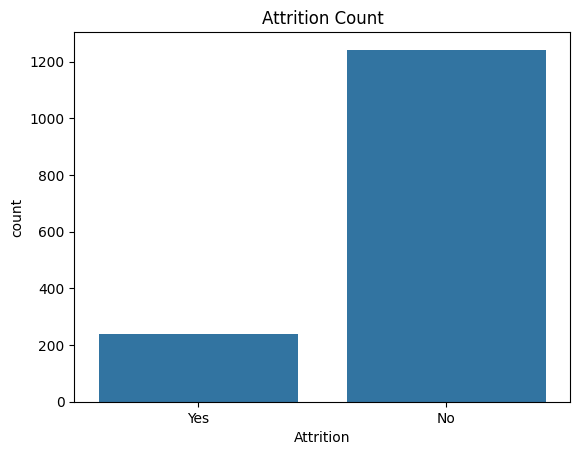

In [8]:
# Attrition Count
sns.countplot(x='Attrition', data=df)
plt.title("Attrition Count")
plt.show()

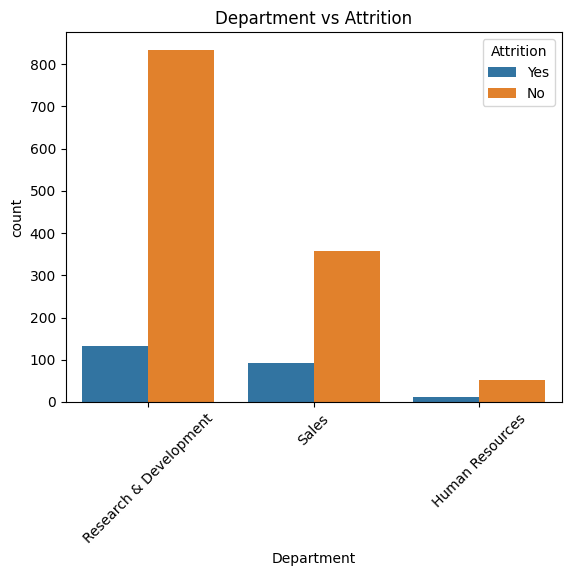

In [9]:
# Department-wise Attrition
sns.countplot(x='Department', hue='Attrition', data=df)
plt.xticks(rotation=45)
plt.title("Department vs Attrition")
plt.show()

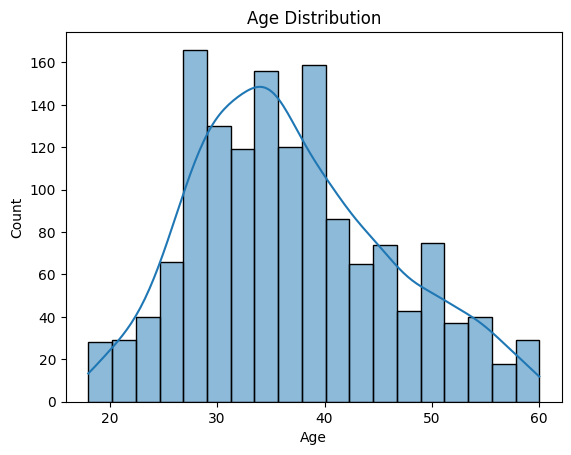

In [10]:
# Age Distribution
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

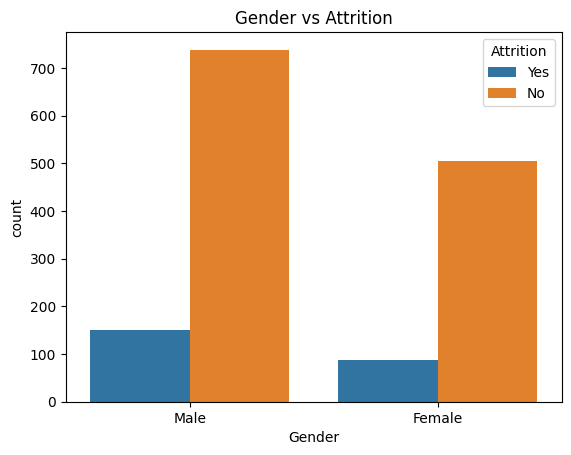

In [11]:
# Gender vs Attrition
sns.countplot(x='Gender', hue='Attrition', data=df)
plt.title("Gender vs Attrition")
plt.show()

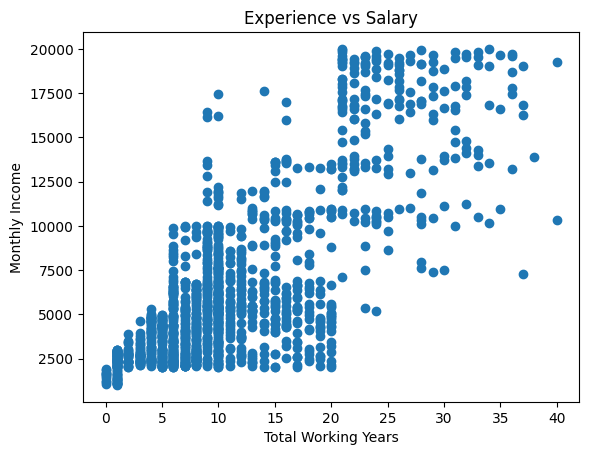

In [12]:
#Salary vs Experience
plt.scatter(df['TotalWorkingYears'], df['MonthlyIncome'])
plt.xlabel("Total Working Years")
plt.ylabel("Monthly Income")
plt.title("Experience vs Salary")
plt.show()

In [13]:
# Overtime vs Attrition
print("\nOverTime vs Attrition:\n",
      pd.crosstab(df['OverTime'], df['Attrition']))


OverTime vs Attrition:
 Attrition   No  Yes
OverTime           
No         952  110
Yes        290  128


In [14]:
#Job Satisfaction
print("\nJob Satisfaction vs Attrition:\n",
      pd.crosstab(df['JobSatisfaction'], df['Attrition']))


Job Satisfaction vs Attrition:
 Attrition         No  Yes
JobSatisfaction          
1                226   67
2                236   46
3                371   73
4                409   52


In [15]:
#Top Salary Roles
top_roles = df.groupby('JobRole')['MonthlyIncome'].mean().sort_values(ascending=False)
print("\nTop Paying Roles:\n", top_roles)


Top Paying Roles:
 JobRole
Manager                      17181.676471
Research Director            16033.550000
Healthcare Representative     7547.416667
Manufacturing Director        7305.258503
Sales Executive               6947.082067
Human Resources               4235.750000
Research Scientist            3241.832765
Laboratory Technician         3239.088123
Sales Representative          2630.047619
Name: MonthlyIncome, dtype: float64
